In [149]:
import pandas as pd
from matplotlib import pyplot as plt

fp = "/playpen/mufan/levi/tianlong-chen-lab/material-super-resolution/__exps__/y-task-formulations/1. P(y | y_sparse)/2024-12-25_17-35-17_hiera_y_bar_y_sparse/results.csv"
df = pd.read_csv(fp)
df.head()

,global_train_step,global_val_step,epoch,train_loss,val_loss,z
0,0.0,NaN,0,0.610683,NaN,NaN
1,1.0,NaN,0,2.049713,NaN,NaN
2,2.0,NaN,0,0.660625,NaN,NaN
3,3.0,NaN,0,0.973355,NaN,NaN
4,4.0,NaN,0,0.595210,NaN,NaN


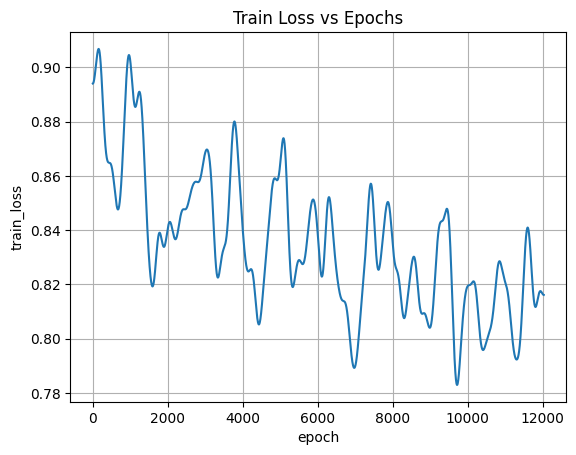

In [150]:
from matplotlib import pyplot as plt
from scipy.ndimage import gaussian_filter1d

SIGMA = 100

_df = df[df["global_train_step"].notna()]
train_steps = _df["global_train_step"]
train_losses = _df["train_loss"]
train_losses_smoothed = gaussian_filter1d(train_losses, sigma=SIGMA)

# plt.plot(train_steps, train_losses)
plt.plot(train_steps, train_losses_smoothed)
plt.xlabel("epoch")
plt.ylabel("train_loss")
plt.title("Train Loss vs Epochs")
plt.grid()
plt.show()

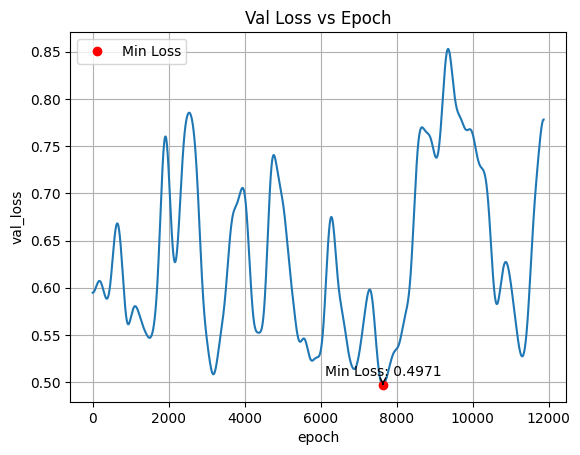

In [151]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# Filter the dataframe to get rows with valid global_val_step
_df = df[df["global_val_step"].notna()]

val_steps = _df["global_val_step"].values
val_losses = _df["val_loss"].values
val_losses_smoothed = gaussian_filter1d(val_losses, sigma=SIGMA)

# Identify the lowest point in the smoothed losses
min_index = np.argmin(val_losses_smoothed)
lowest_val_epoch = val_steps[min_index]
lowest_val_loss = val_losses_smoothed[min_index]

# Plot the smoothed loss
plt.plot(val_steps, val_losses_smoothed)
plt.xlabel("epoch")
plt.ylabel("val_loss")
plt.title("Val Loss vs Epoch")
plt.grid(True)

# Plot a red dot at the lowest loss point
plt.plot(lowest_val_epoch, lowest_val_loss, 'ro', label='Min Loss')
 
# Annotate the lowest loss value on the figure
plt.annotate(f'Min Loss: {lowest_val_loss:.4f}',
             xy=(lowest_val_epoch, lowest_val_loss), 
             xytext=(lowest_val_epoch, lowest_val_loss + 0.010), 
             arrowprops=dict(facecolor='black', arrowstyle='->'),
             ha='center')

plt.legend()
plt.show()

In [152]:
import numpy as np

f"{(np.mean(train_losses[-500: ]) * 100):.5f}%", f"{(np.mean(val_losses[-500: ])):.5f}%"

('82.30577%', '0.67130%')

In [153]:
# 13232
val_losses = _df["val_loss"]
val_losses

256      0.509107
257      0.497682
258      0.477636
259      0.633916
260      0.502783
           ...   
23893    0.721528
23894    0.729393
23895    1.166808
23896    0.729566
23897    0.725458
Name: val_loss, Length: 11866, dtype: float64